In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler


## **Import data**

In [2]:
data_path=r'../00_data/02_processed'
df=pd.read_csv(data_path+'/'+'ecommerce_data.csv')

In [7]:
# Convertir matriz 

df['coupon_status_binary'] = df['coupon_status'].map(lambda x: 1 if x == 'Used' else 0)

columns_selected = ['invoice_value','quantity','product_sku','transaction_date','transaction_id',
                    'product_category','coupon_code','coupon_status_binary']

distinct_count = lambda x: len(np.unique(x.astype(str)))

tabla_groupby = df.groupby("customer_id").agg({
    'invoice_value': 'sum',
    'quantity': 'sum',
    'product_sku': distinct_count,
    'transaction_date': distinct_count,
    'transaction_id': distinct_count,
    'product_category': distinct_count,
    'coupon_code': distinct_count,
    'coupon_status_binary': 'sum'
})

tabla_groupby = tabla_groupby.rename(columns={
    'invoice_value': 'total_invoice',
    'quantity': 'total_quantity',
    'product_sku': 'cant_products',
    'transaction_date': 'freq_purchase',
    'transaction_id': 'cant_transactions',
    'product_category': 'cant_categories',
    'coupon_code': 'cant_coupons',
    'coupon_status_binary': 'cant_coupons_used'
})
tabla_groupby
tabla_groupby.to_csv('tabla_groupby.csv', index=True)


In [5]:

# Escalar los datos con StandardScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(tabla_groupby)

# Convertir a DataFrame
scaled_df = pd.DataFrame(data_scaled, columns=tabla_groupby.columns)

# Reemplazar valores infinitos o NaN con la media de la columna
scaled_df.replace([np.inf, -np.inf], np.nan, inplace=True)
scaled_df.fillna(scaled_df.mean(), inplace=True)

# Mostrar primeras filas del dataset escalado
display(scaled_df.head())

,total_invoice,total_quantity,cant_products,freq_purchase,cant_transactions,cant_categories,cant_coupons,cant_coupons_used
0,0.001933,0.000411,0.003257,0.000000,0.000000,0.055556,0.027027,0.007937
1,0.180447,0.070049,0.133550,0.060606,0.091743,0.500000,0.324324,0.079365
2,0.019363,0.042728,0.065147,0.030303,0.021407,0.277778,0.243243,0.043651
3,0.016807,0.004108,0.032573,0.000000,0.030581,0.166667,0.081081,0.023810
4,0.023021,0.011298,0.104235,0.000000,0.036697,0.333333,0.135135,0.043651


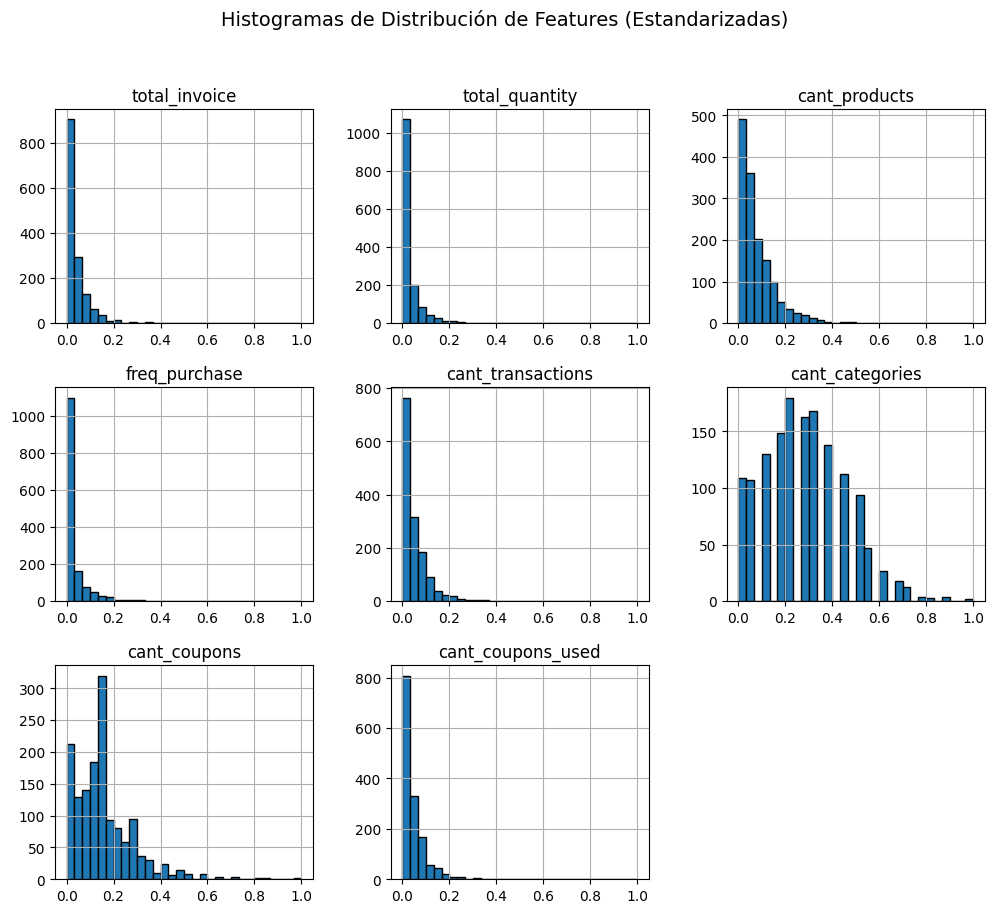

In [21]:
# Configuración del gráfico
scaled_df.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle("Histogramas de Distribución de Features (Estandarizadas)", fontsize=14)
plt.show()


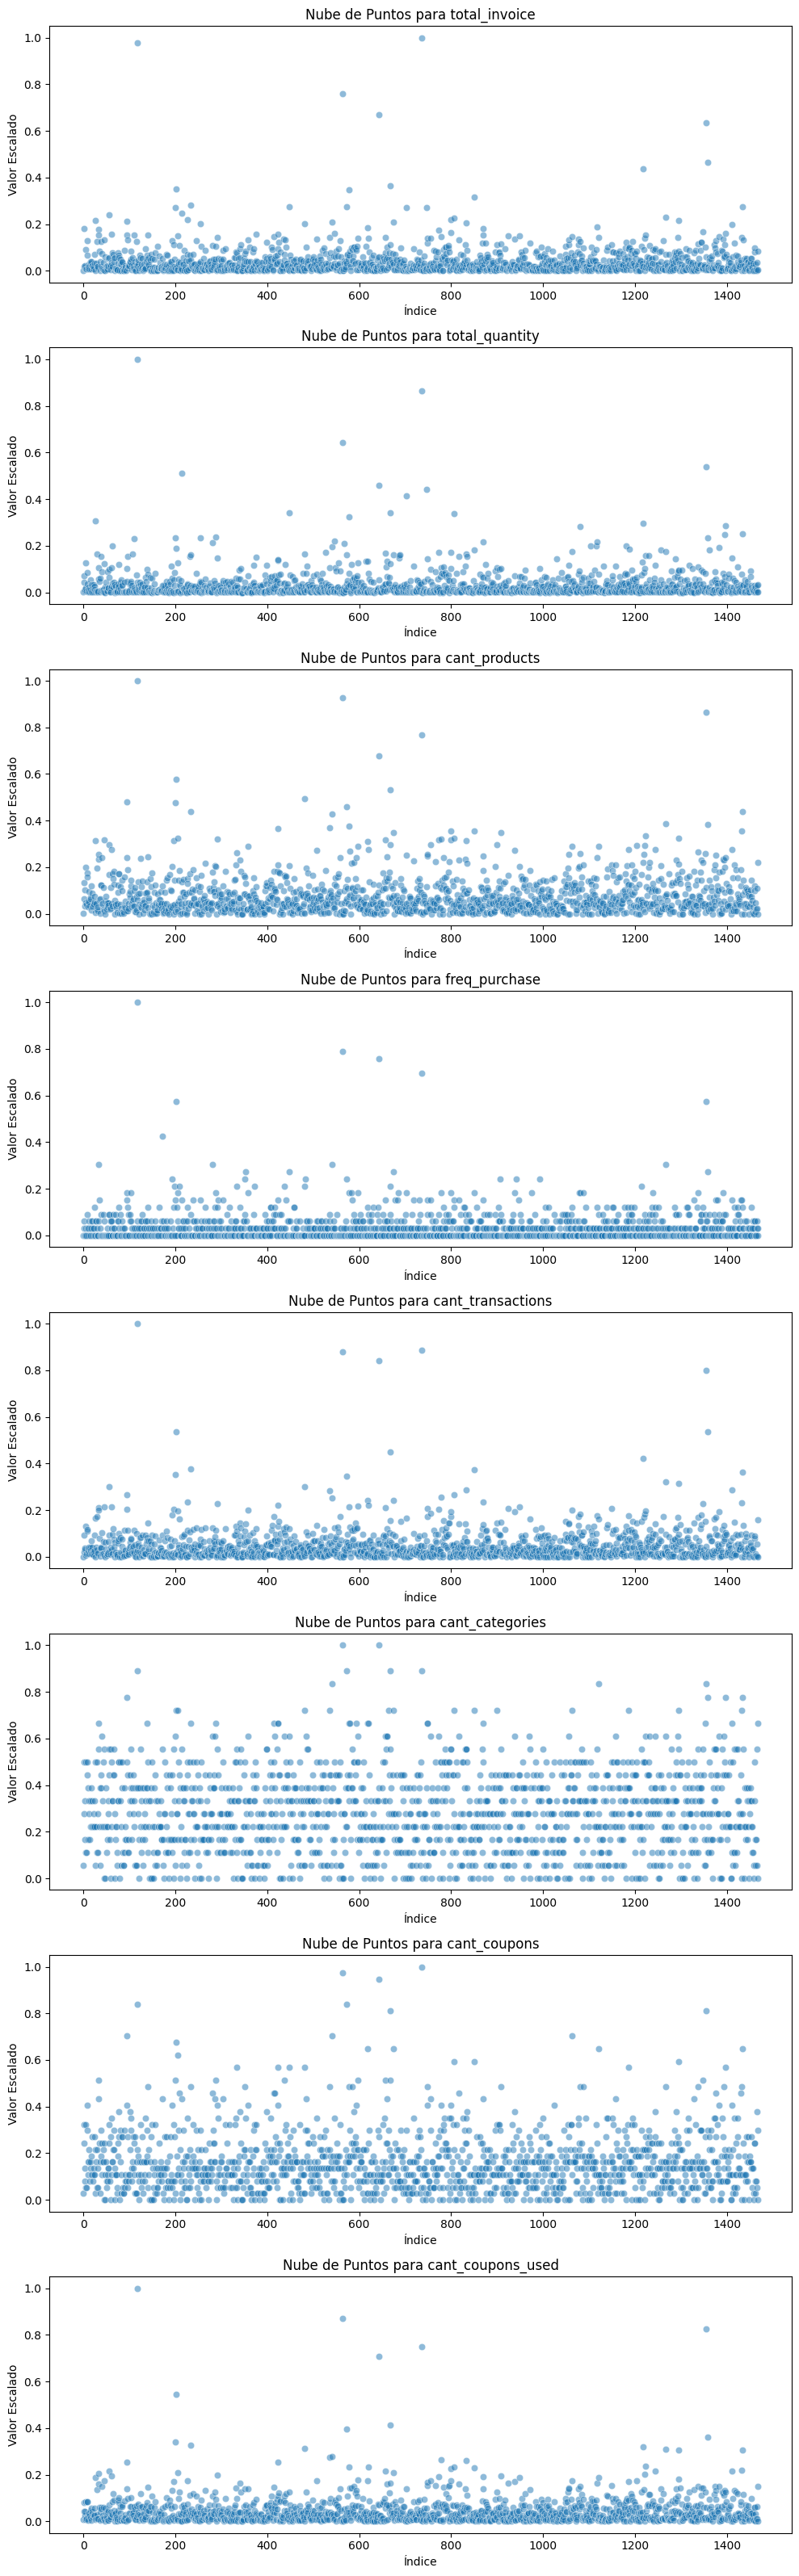

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear subgráficos para cada feature
num_features = len(scaled_df.columns)
fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(10, 4 * num_features))

# Graficar cada feature
for i, column in enumerate(scaled_df.columns):
    sns.scatterplot(x=scaled_df.index, y=scaled_df[column], alpha=0.5, ax=axes[i])
    axes[i].set_title(f"Nube de Puntos para {column}")
    axes[i].set_xlabel("Índice")
    axes[i].set_ylabel("Valor Escalado")

plt.tight_layout()
plt.show()


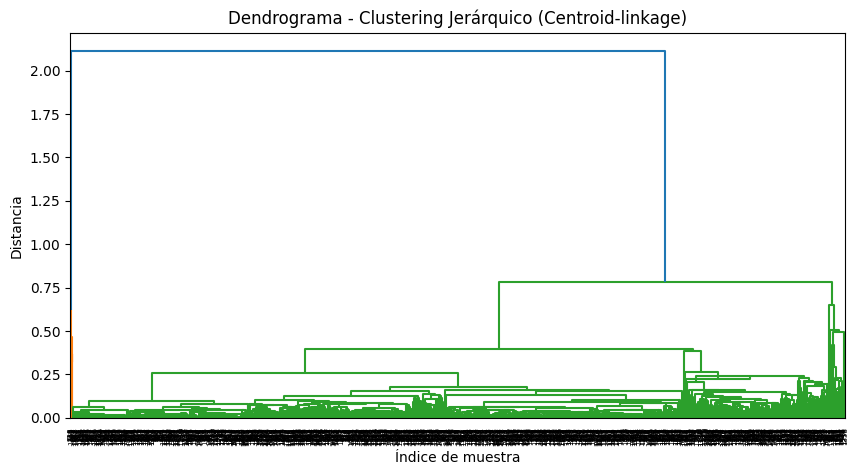

In [6]:
# Aplicar clustering jerárquico con Centroid-linkage
Z = linkage(data_scaled, method='centroid')

# Graficar el dendrograma
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrograma - Clustering Jerárquico (Centroid-linkage)")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia")
plt.show()

In [18]:
from scipy.cluster.hierarchy import fcluster

# Elegir un umbral adecuado para cortar el dendrograma
num_clusters = 4  # Ajustar según el dendrograma
clusters = fcluster(Z, num_clusters, criterion='maxclust')

# Agregar la etiqueta de cluster al DataFrame original
tabla_groupby['cluster'] = clusters

# Mostrar la cantidad de elementos por cluster
tabla_groupby['cluster'].value_counts()


cluster
2    1432
3      30
1       5
4       1
Name: count, dtype: int64

In [19]:
# Promedio de cada variable por cluster
cluster_analysis = tabla_groupby.groupby('cluster').mean()
print(cluster_analysis)

         total_invoice  total_quantity  cant_products  freq_purchase  \
cluster                                                                
1         69888.130020     3369.600000     257.600000      26.200000   
2          3047.279092      130.965782      22.836592       2.001397   
3         20561.610646     1035.066667     104.666667       6.333333   
4         30416.776110      924.000000     175.000000      20.000000   

         cant_transactions  cant_categories  cant_coupons  cant_coupons_used  
cluster                                                                       
1               288.200000        14.800000     33.800000         207.400000  
2                15.590782         5.668296      6.289106          10.334497  
3                87.400000        12.100000     20.366667          60.233333  
4               175.000000        13.000000     25.000000         135.000000  


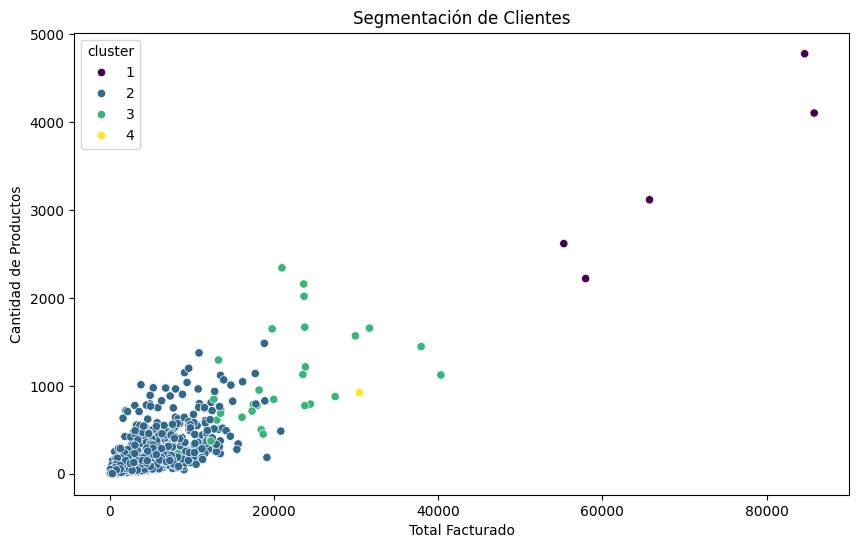

In [20]:
import seaborn as sns

# Elegir dos variables importantes para visualizar
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tabla_groupby['total_invoice'], y=tabla_groupby['total_quantity'], hue=tabla_groupby['cluster'], palette='viridis')
plt.title("Segmentación de Clientes")
plt.xlabel("Total Facturado")
plt.ylabel("Cantidad de Productos")
plt.show()


In [28]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import numpy as np

def calcular_silhouette_linkage(X, max_clusters=10, method='centroid'):
    """
    Calcula el Silhouette Score para diferentes números de clusters en Linkage.

    Parámetros:
    - X: Datos escalados (numpy array o DataFrame).
    - max_clusters: Número máximo de clusters a evaluar.
    - method: Método de linkage ('ward', 'complete', 'average', 'centroid').

    Retorna:
    - Un diccionario con {num_clusters: silhouette_score}.
    """
    silhouette_scores = {}

    # Aplicar clustering jerárquico con el método seleccionado
    Z = linkage(X, method=method)

    for k in range(2, max_clusters + 1):  # Evaluamos desde 2 hasta max_clusters clusters
        labels = fcluster(Z, k, criterion='maxclust')  # Asignar clusters

        # Evitar errores si solo hay 1 cluster único
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
            silhouette_scores[k] = score
        else:
            silhouette_scores[k] = -1  # Penalizar caso con 1 solo cluster

    return silhouette_scores

# Ejemplo de uso
silhouette_results = calcular_silhouette_linkage(scaled_df, max_clusters=10)

# Mostrar resultados
for k, score in silhouette_results.items():
    print(f"Clusters: {k}, Silhouette Score: {score}")



Clusters: 2, Silhouette Score: 0.8563689912799861
Clusters: 3, Silhouette Score: 0.6427663069863029
Clusters: 4, Silhouette Score: 0.6322111374819374
Clusters: 5, Silhouette Score: 0.6314961713464478
Clusters: 6, Silhouette Score: 0.5512844637562769
Clusters: 7, Silhouette Score: 0.5505972935039978
Clusters: 8, Silhouette Score: 0.5504072942538988
Clusters: 9, Silhouette Score: 0.5493285374556428
Clusters: 10, Silhouette Score: 0.5464977371285213


In [26]:
!pip install pyswarms

  Using cached attrs-25.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached PyYAML-6.0.2-cp313-cp313-win_amd64.whl.metadata (2.1 kB)
Using cached PyYAML-6.0.2-cp313-cp313-win_amd64.whl (156 kB)



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Suponiendo que ya tienes tu dataset escalado en un DataFrame llamado df_scaled_df
# Convertirlo a array (X) para trabajar con numpy
X = data_scaled
n_samples, feature_dim = X.shape
num_cluster = 4  # Fijamos 4 clusters
dimensions = num_cluster * feature_dim  # Cada cluster tiene 'feature_dim' coordenadas

# Definir los límites para cada dimensión (centroide)
# Si tus datos están escalados (media 0, desviación 1), se puede considerar un rango razonable, por ejemplo [-1, 1]
max_bound = 1 * np.ones(dimensions)
min_bound = -1 * np.ones(dimensions)
bounds = (min_bound, max_bound)

# Hiperparámetros del PSO
options = {'c1': 2, 'c2': 2, 'w': 0.9}
n_particles = 20


Paso 2: Definir la función objetivo (fitness function)
La función objetivo se encargará de:

Interpretar cada partícula como un conjunto de 4 centroides (cada uno de dimensión feature_dim).
Calcular, para cada muestra, la distancia euclidiana al centroide (utilizando la suma de diferencias al cuadrado).
Asignar a cada muestra el cluster del centroide más cercano.
Calcular el Silhouette Score para la partición.
Retornar la función fitness como 1 - Silhouette Score (de forma que minimizar la función equivale a maximizar el Silhouette Score).
En caso de que la asignación resulte en un único cluster, se penaliza la solución.

In [30]:
def funcion_objetivo(solution):
    """
    Función objetivo para PSO.
    Cada partícula es una posible solución de dimensión (num_cluster * feature_dim).
    Se calcula el Silhouette Score y se retorna 1 - Silhouette Score para minimizar.
    """
    n_particles = solution.shape[0]
    fitness = np.zeros(n_particles)
    
    # Matriz para almacenar las distancias: forma (n_samples, num_cluster)
    distance = np.zeros((n_samples, num_cluster))
    
    # Para cada partícula (solución candidata)
    for j in range(n_particles):
        # Extraer los centroides de la solución
        # Cada centroide se encuentra en una porción de tamaño feature_dim
        centroids = []
        for i in range(num_cluster):
            start = i * feature_dim
            end = start + feature_dim
            centroid = solution[j, start:end]
            centroids.append(centroid)
            # Calcular la distancia al cuadrado de cada muestra a este centroide
            # Guardamos en la columna correspondiente
            distance[:, i] = np.sum((X - centroid) ** 2, axis=1)
            
        # Asignar cada muestra al cluster cuyo centroide sea el más cercano
        labels = np.argmin(distance, axis=1)
        
        # Penalizar la solución si todos los puntos se asignan a un único cluster
        if len(np.unique(labels)) == 1:
            fitness[j] = 1.0
        else:
            score = silhouette_score(X, labels)
            fitness[j] = 1 - score  # Queremos minimizar; al minimizar 1 - score maximizamos score
            
    return fitness


Paso 3: Configurar y ejecutar el optimizador PSO
Utilizamos el optimizador GlobalBestPSO de pyswarms, configurándolo con los parámetros definidos y los límites para cada dimensión. Luego, ejecutamos la optimización durante un número determinado de iteraciones.

In [31]:
# Inicializar el optimizador PSO
optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, 
                                    dimensions=dimensions, 
                                    options=options, 
                                    bounds=bounds)

# Ejecutar la optimización (por ejemplo, durante 50 iteraciones)
cost, pos = optimizer.optimize(funcion_objetivo, iters=50)

# Extraer la mejor solución encontrada
best_solution = optimizer.swarm.best_pos
print(f"Parámetros de la mejor solución: {best_solution}")


2025-03-02 11:09:02,051 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 2, 'c2': 2, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.127
2025-03-02 11:09:42,046 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.1272392835505256, best pos: [ 0.02503688 -0.58309323  0.94637994 -0.6415385   0.25431377 -0.86003895
  0.39322515 -0.52489799  0.45469808  0.17257727  0.11601353  0.88882458
  0.68715267 -0.41257785 -0.63254682 -0.51833977  0.33903258  0.4834505
 -0.60430732  0.13612301 -0.44958441 -0.25179353  0.49636225 -0.90553341
 -0.53306991  0.3914898   0.19317718 -0.06991821 -0.70563978  0.12040424
  0.5489641   0.78285837]


Parámetros de la mejor solución: [ 0.02503688 -0.58309323  0.94637994 -0.6415385   0.25431377 -0.86003895
  0.39322515 -0.52489799  0.45469808  0.17257727  0.11601353  0.88882458
  0.68715267 -0.41257785 -0.63254682 -0.51833977  0.33903258  0.4834505
 -0.60430732  0.13612301 -0.44958441 -0.25179353  0.49636225 -0.90553341
 -0.53306991  0.3914898   0.19317718 -0.06991821 -0.70563978  0.12040424
  0.5489641   0.78285837]


Paso 4: Evaluar la solución y obtener los clusters
Con la mejor solución, se extraen los centroides y se asignan los clusters para cada muestra del dataset. Se calcula el Silhouette Score final y se muestran los resultados.

In [32]:
# Calcular las distancias con la mejor solución
distance = np.zeros((n_samples, num_cluster))
centroids = []
for i in range(num_cluster):
    start = i * feature_dim
    end = start + feature_dim
    centroid = best_solution[start:end]
    centroids.append(centroid)
    distance[:, i] = np.sum((X - centroid) ** 2, axis=1)

# Asignar cada muestra al cluster del centroide más cercano
PSO_labels = np.argmin(distance, axis=1)
final_score = silhouette_score(X, PSO_labels)
print(f"Silhouette Score final: {final_score}")


Silhouette Score final: 0.8727607164494744
